In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('amazon.csv')

In [5]:
df.head()

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


In [6]:
df.shape

(20000, 2)

In [15]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("vader_lexicon")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:
def preprocess_text(text):
  tokens = word_tokenize(text.lower())
  filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]
  lemmatizer = WordNetLemmatizer()
  lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
  return ' '.join(lemmatized_tokens)


In [19]:
df["reviewText"] = df["reviewText"].apply(preprocess_text)


In [20]:
df.head()

,reviewText,Positive
0,one best apps acording bunch people agree bomb...,1
1,pretty good version game free . lot different ...,1
2,really cool game . bunch level find golden egg...,1
3,"silly game frustrating , lot fun definitely re...",1
4,terrific game pad . hr fun . grandkids love . ...,1


In [21]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [22]:
analyzer = SentimentIntensityAnalyzer()

In [24]:
def get_sentiment(text):
  scores = analyzer.polarity_scores(text)
  sentiment = 1 if scores["pos"] > 0 else 0
  return sentiment

In [26]:
df["sentiment"] = df["reviewText"].apply(get_sentiment)

In [27]:
df.head()

,reviewText,Positive,sentiment
0,one best apps acording bunch people agree bomb...,1,1
1,pretty good version game free . lot different ...,1,1
2,really cool game . bunch level find golden egg...,1,1
3,"silly game frustrating , lot fun definitely re...",1,1
4,terrific game pad . hr fun . grandkids love . ...,1,1


In [30]:
scores = analyzer.polarity_scores("one best apps acording bunch people agree bomb")
scores

{'neg': 0.215, 'neu': 0.336, 'pos': 0.45, 'compound': 0.5423}

In [33]:
from sklearn.metrics import confusion_matrix
result = confusion_matrix(df["Positive"],df["sentiment"])
result

array([[ 1131,  3636],
       [  576, 14657]])

In [34]:
from sklearn.metrics import classification_report
print(classification_report(df["Positive"],df["sentiment"]))

              precision    recall  f1-score   support

           0       0.66      0.24      0.35      4767
           1       0.80      0.96      0.87     15233

    accuracy                           0.79     20000
   macro avg       0.73      0.60      0.61     20000
weighted avg       0.77      0.79      0.75     20000



In [35]:
import seaborn as sns
import matplotlib.pyplot as plt


<Axes: xlabel='Predicted', ylabel='Actual'>

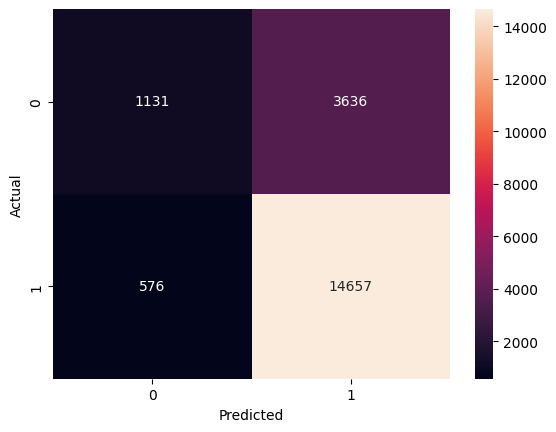

In [40]:
c_mtrix = pd.crosstab(df["Positive"],df["sentiment"], rownames=["Actual"], colnames=["Predicted"])
c_mtrix
sns.heatmap(c_mtrix, annot=True, fmt=".0f")
